In [1]:
!pip install datasets
!pip install textstat
!pip install bert_score
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 kB 10.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd


In [4]:
# Define the file paths
file_path_original = '/content/drive/MyDrive/MEDICAL/DATASET/complex_text.txt'
file_path_simple = '/content/drive/MyDrive/MEDICAL/DATASET/simple_text.txt'

In [5]:
# Reading the content of both files, specifying the encoding
with open(file_path_original, 'r', encoding='latin-1') as original_file:  # Try 'latin-1' first
    original_text = original_file.read()

with open(file_path_simple, 'r', encoding='latin-1') as simple_file:  # Try 'latin-1' for consistency
    simple_text = simple_file.read()

In [6]:
# Split the original and simple text into lines to prepare for storing them in a dataframe
original_lines = original_text.splitlines()
simple_lines = simple_text.splitlines()

# Removing empty lines from both texts
original_lines_cleaned = [line for line in original_lines if line.strip() != '']
simple_lines_cleaned = [line for line in simple_lines if line.strip() != '']

In [7]:
# Pad the shorter list (simple_lines_cleaned) with empty strings to match the length of the original_lines_cleaned
while len(simple_lines_cleaned) < len(original_lines_cleaned):
    simple_lines_cleaned.append('')

# Create a dataframe with two columns: 'Original' and 'Simple'
data = {
    "Original": original_lines_cleaned,
    "Simple": simple_lines_cleaned
}

In [8]:
df = pd.DataFrame(data)
df = df.iloc[:-12]
df.head()

,Original,Simple
0,The patient presented with a history of chroni...,The patient came in with worsening COPD sympto...
1,The patient was diagnosed with type 2 diabetes...,The patient was diagnosed with type 2 diabetes...
2,A 45-year-old male presented to the emergency ...,A 45-year-old man came to the emergency room w...
3,"The patient, a 62-year-old female, presented w...",A 62-year-old woman came in with worsening low...
4,"The patient, a 50-year-old male with a history...",A 50-year-old man with a history of high blood...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Original  261 non-null    object
 1   Simple    261 non-null    object
dtypes: object(2)
memory usage: 4.2+ KB


In [10]:
for i in range(5):
  print('Actual :' ,df.iloc[i,0])
  print('-----' * 50)
  print('Simple :', df.iloc[i,1])
  print('-----' * 50)

Actual : The patient presented with a history of chronic obstructive pulmonary disease (COPD) exacerbation, accompanied by increased dyspnea, wheezing, and productive cough. Despite previous treatment with bronchodilators and corticosteroids, the symptoms had worsened over the past week. On examination, the patient had a respiratory rate of 28 breaths per minute, and oxygen saturation was 88% on room air. Auscultation revealed bilateral wheezing and diminished breath sounds. A chest X-ray was ordered to rule out pneumonia, and the patient was started on antibiotics and supplemental oxygen. The decision was made to admit the patient for further observation and management of the acute COPD exacerbation.
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Simple : The patient came in with wors

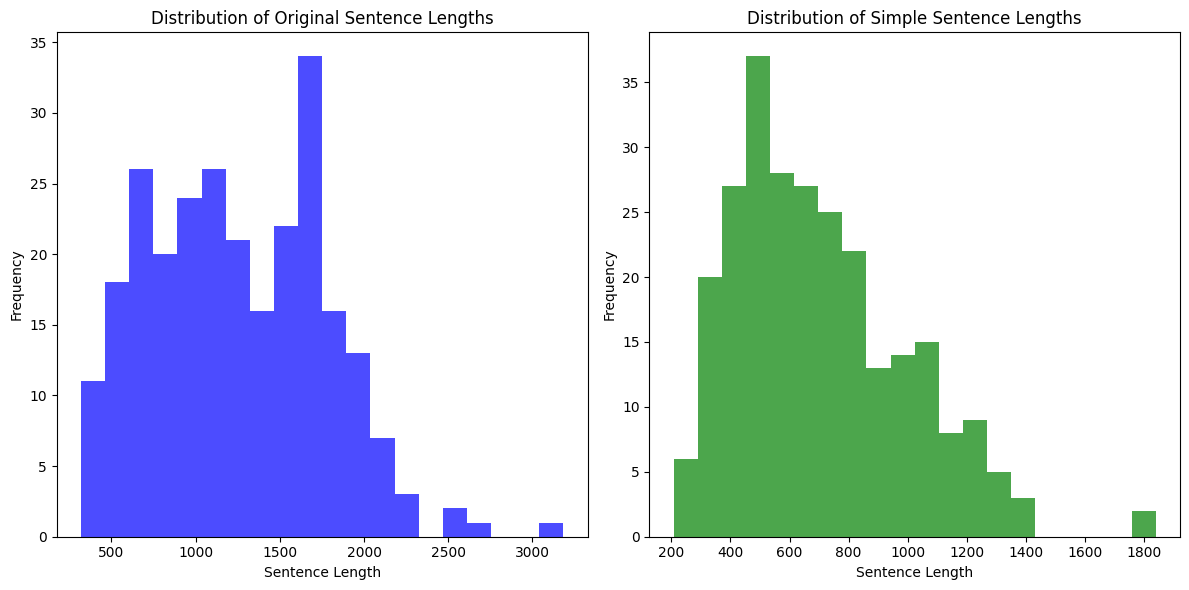

In [11]:

import matplotlib.pyplot as plt

# Calculate the length of each sentence in both columns
df['Original Length'] = df['Original'].apply(len)
df['Simple Length'] = df['Simple'].apply(len)

# Plot the histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['Original Length'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Original Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['Simple Length'], bins=20, color='green', alpha=0.7)
plt.title('Distribution of Simple Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


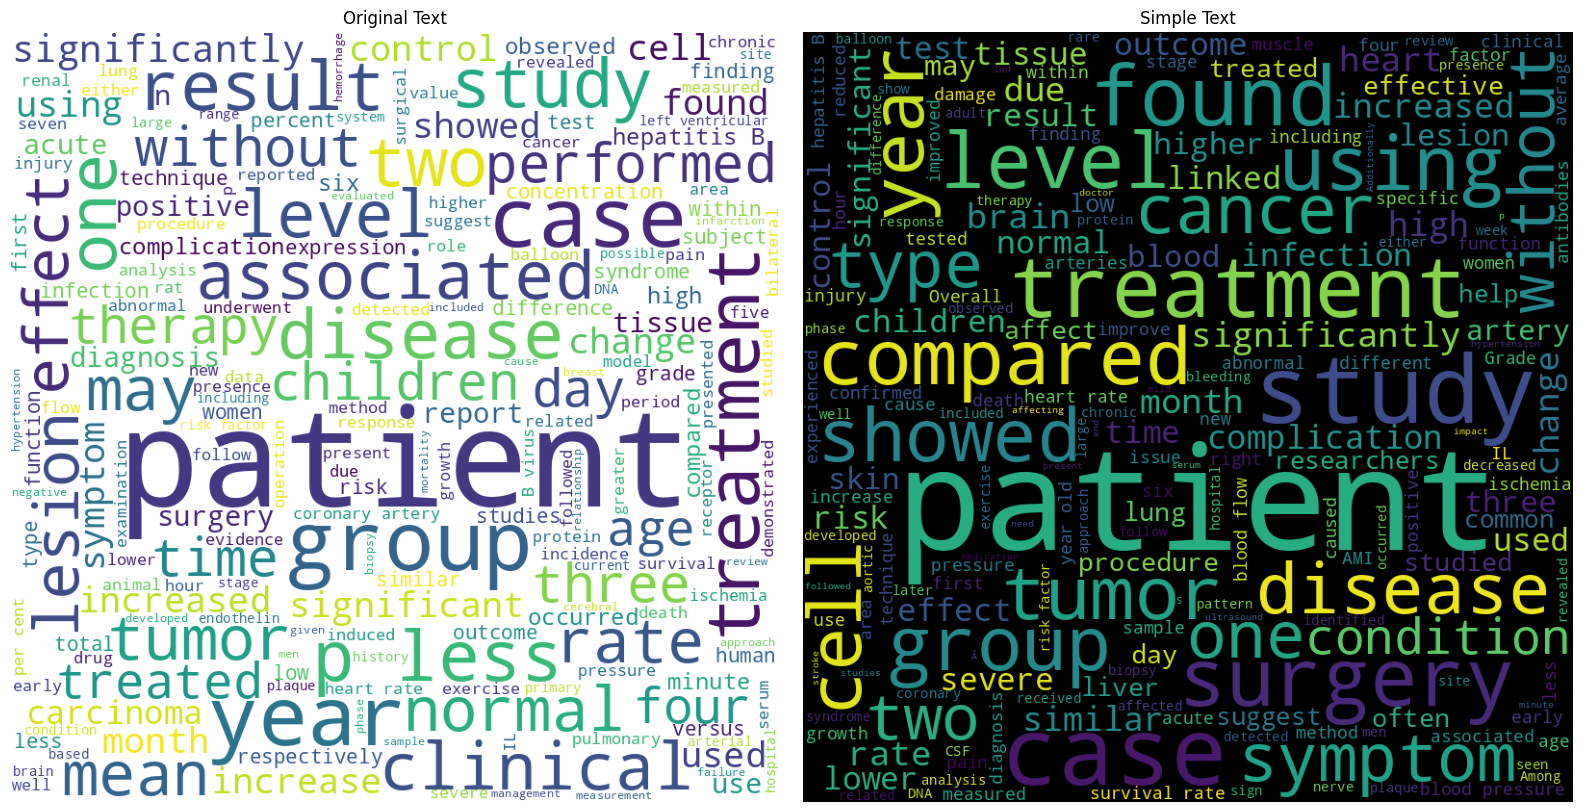

In [12]:

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Create stopwords
stopwords = set(STOPWORDS)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot word cloud for 'Original' column
wordcloud_original = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(' '.join(df['Original']))

axs[0].imshow(wordcloud_original)
axs[0].axis("off")
axs[0].set_title('Original Text')

# Plot word cloud for 'Simple' column
wordcloud_simple = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = stopwords,
                min_font_size = 10).generate(' '.join(df['Simple']))

axs[1].imshow(wordcloud_simple)
axs[1].axis("off")
axs[1].set_title('Simple Text')

plt.tight_layout()
plt.show()


In [13]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import pandas as pd
from datasets import Dataset as HFDataset
from transformers import BartTokenizer, BartForConditionalGeneration, DataCollatorForSeq2Seq
from torch.utils.data import DataLoader
import torch


In [14]:
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [15]:
def preprocess_text(text):
    lemmatizer, stop_words = WordNetLemmatizer(), set(stopwords.words('english'))
    return ' '.join(
        lemmatizer.lemmatize(w, 'a' if t.startswith('J') else 'v' if t.startswith('V') else 'n' if t.startswith('N') else 'r' if t.startswith('R') else 'n')
        for w, t in pos_tag(word_tokenize(text.lower())) if w.isalnum() and w not in stop_words
    )


In [16]:
# Prepare dataset from pandas DataFrame
def prepare_dataset(df):
    df['input_text'] = df['Original'].apply(preprocess_text)
    df['target_text'] = df['Simple'].apply(preprocess_text)
    data = {'input_text': df['input_text'].tolist(), 'target_text': df['target_text'].tolist()}
    return HFDataset.from_dict(data)

In [17]:
# Prepare and preprocess dataset
dataset = prepare_dataset(df)

# PEGASUS

In [18]:
import matplotlib.pyplot as plt
!pip install transformers torch sentencepiece

In [19]:
!pip install transformers datasets torch


In [20]:
from transformers import PegasusTokenizer, PegasusForConditionalGeneration, DataCollatorForSeq2Seq
from torch.utils.data import DataLoader
import torch

# Load the tokenizer and model
model_name = "google/pegasus-large"
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.09k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-large and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

In [21]:
def tokenize_function(examples):
    model_inputs = tokenizer(examples['input_text'], max_length=1024, truncation=True, padding="max_length")
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(examples['target_text'], max_length=1024, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["input_text", "target_text"])


Map:   0%|          | 0/261 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:4016: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [22]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

train_dataloader = DataLoader(tokenized_dataset, shuffle=True, batch_size=1, collate_fn=data_collator)


In [23]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

losses = []
import matplotlib.pyplot as plt

# Enable gradient accumulation to simulate a larger batch size
gradient_accumulation_steps = 2  # Adjust as needed

model.train()
for epoch in range(35):
    for i, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss / gradient_accumulation_steps  # Normalize the loss
        losses.append(loss.item())

        loss.backward()

        # Accumulate gradients
        if (i + 1) % gradient_accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        print(f"Epoch: {epoch}, Step: {i}, Loss: {loss.item()}")





Streaming output truncated to the last 5000 lines.
Epoch: 15, Step: 220, Loss: 0.2643195688724518
Epoch: 15, Step: 221, Loss: 0.21390584111213684
Epoch: 15, Step: 222, Loss: 0.05650022625923157
Epoch: 15, Step: 223, Loss: 0.07914326339960098
Epoch: 15, Step: 224, Loss: 0.08378217369318008
Epoch: 15, Step: 225, Loss: 0.1750229150056839
Epoch: 15, Step: 226, Loss: 0.09671704471111298
Epoch: 15, Step: 227, Loss: 0.3004261553287506
Epoch: 15, Step: 228, Loss: 0.06581252813339233
Epoch: 15, Step: 229, Loss: 0.17278194427490234
Epoch: 15, Step: 230, Loss: 0.09014515578746796
Epoch: 15, Step: 231, Loss: 0.11812688410282135
Epoch: 15, Step: 232, Loss: 0.0946323573589325
Epoch: 15, Step: 233, Loss: 0.10493357479572296
Epoch: 15, Step: 234, Loss: 0.049155157059431076
Epoch: 15, Step: 235, Loss: 0.0662020742893219
Epoch: 15, Step: 236, Loss: 0.1046256572008133
Epoch: 15, Step: 237, Loss: 0.08260972052812576
Epoch: 15, Step: 238, Loss: 0.04028797149658203
Epoch: 15, Step: 239, Loss: 0.118417210876

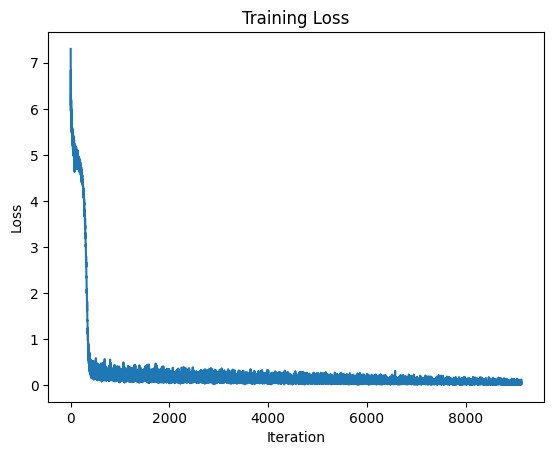

In [24]:
# Plot the losses
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [25]:
from datasets import load_metric


In [26]:
import evaluate

# Load BLEU and COMET metrics
bleu_metric = evaluate.load("bleu", trust_remote_code=True)
nltk.download('punkt')
bert_score_metric = load_metric("bertscore", trust_remote_code=True)
meteor_metric = load_metric('meteor', trust_remote_code=True)

# Import BLEU and COMET
from datasets import load_metric

# Load BLEU and COMET metrics
bleu_metric = load_metric("bleu", trust_remote_code=True)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
<ipython-input-26-14f30f86f408>:6: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  bert_score_metric = load_metric("bertscore", trust_remote_code=True)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [27]:
# prompt: create a Function to generate simplified text

def generate_simplified_text(text, model, tokenizer, max_length=1024):
    inputs = tokenizer(text, max_length=max_length, return_tensors="pt", truncation=True, padding="max_length").to(device)
    summary_ids = model.generate(inputs.input_ids, attention_mask=inputs.attention_mask, max_length=max_length)
    simplified_text = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return simplified_text


In [28]:

# # Sample 10 random rows
# sample_indices = df.sample(10).index

# # Iterate over the sampled rows and print actual vs predicted
# for idx in sample_indices:
#     original_text = df.loc[idx, 'Original']
#     simple_text = df.loc[idx, 'Simple']
#     predicted_simple_text = generate_simplified_text(original_text, model, tokenizer)

#     print("Original Text:")
#     print(original_text)
#     print("\nActual Simple Text:")
#     print(simple_text)
#     print("\nPredicted Simple Text:")
#     print(predicted_simple_text)
#     print("----" * 20)


In [29]:
from datasets import load_metric
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from textstat import flesch_kincaid_grade

In [30]:
# Evaluation Functions
def evaluate_readability(text):
    fkgl = flesch_kincaid_grade(text)
    return fkgl

from nltk.translate.bleu_score import sentence_bleu

# Ensure you have downloaded the necessary NLTK data files
nltk.download('punkt')

def evaluate_metrics(pred_text, ref_text):
    # Readability score
    fkgl = evaluate_readability(pred_text)

    # BERTScore
    bert_score = bert_score_metric.compute(predictions=[pred_text], references=[ref_text], lang="en")

    # METEOR score
    meteor = meteor_metric.compute(predictions=[pred_text], references=[ref_text])['meteor']

    # BLEU score
    reference_tokens = nltk.word_tokenize(ref_text)
    prediction_tokens = nltk.word_tokenize(pred_text)
    bleu = sentence_bleu([reference_tokens], prediction_tokens)

    return fkgl, bert_score, meteor, bleu

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [31]:
# Define the file paths for your evaluation data
eval_file_path_original = '/content/drive/MyDrive/MEDICAL/DATASET/original_text.txt'
eval_file_path_simple = '/content/drive/MyDrive/MEDICAL/DATASET/simplified_text.txt'

In [32]:
# Load the evaluation data
with open(eval_file_path_original, 'r', encoding='latin-1') as original_file:
    eval_original_text = original_file.read()

with open(eval_file_path_simple, 'r', encoding='latin-1') as simple_file:
    eval_simple_text = simple_file.read()


In [33]:

# Split the texts into lines
eval_original_lines = eval_original_text.splitlines()
eval_simple_lines = eval_simple_text.splitlines()

# Removing empty lines from both texts
eval_original_lines = [line for line in eval_original_lines if line.strip() != '']
eval_simple_lines = [line for line in eval_simple_lines if line.strip() != '']


In [34]:



# Preprocess the evaluation data (similar to training data)
eval_original_lines = [preprocess_text(line) for line in eval_original_lines]
eval_simple_lines = [preprocess_text(line) for line in eval_simple_lines]

In [35]:

# Initialize lists to store metric values
fkgl_scores = []
bert_scores = []
meteor_scores = []
bleu_scores = []

# Evaluate and store metrics for each pair of sentences
for original, simple in zip(eval_original_lines, eval_simple_lines):
    simplified_text = generate_simplified_text(original, model, tokenizer)

    fkgl, bert_score, meteor, bleu = evaluate_metrics(simplified_text, simple)

    fkgl_scores.append(fkgl)
    bert_scores.append(bert_score['f1'][0])
    meteor_scores.append(meteor)
    bleu_scores.append(bleu)

# Calculate and print average metrics
avg_fkgl = sum(fkgl_scores) / len(fkgl_scores)
avg_bert_score = sum(bert_scores) / len(bert_scores)
avg_meteor = sum(meteor_scores) / len(meteor_scores)
avg_bleu = sum(bleu_scores) / len(bleu_scores)




tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [36]:
print("\nAverage Metrics:")
print("-" * 20)
print("Average Flesch-Kincaid Grade Level:", avg_fkgl)
print("Average BERTScore:", avg_bert_score)
print("Average METEOR Score:", avg_meteor)
print("Average BLEU Score:", avg_bleu)


Average Metrics:
--------------------
Average Flesch-Kincaid Grade Level: 21.25
Average BERTScore: 0.9492780029773712
Average METEOR Score: 0.7852448748198995
Average BLEU Score: 0.5825745487805342


In [2]:

# Sample 2 random rows from the evaluation data
import random
sample_indices = random.sample(range(len(eval_original_lines)), 2)

# Iterate over the sampled rows and print actual vs predicted
for idx in sample_indices:
    original_text = eval_original_lines[idx]
    simple_text = eval_simple_lines[idx]
    predicted_simple_text = generate_simplified_text(original_text, model, tokenizer)

    print("Original Text:")
    print(original_text)
    print("\nActual Simple Text:")
    print(simple_text)
    print("\nPredicted Simple Text:")
    print(predicted_simple_text)
    print("----" * 20)


NameError: name 'eval_original_lines' is not defined